In [1]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from LBFGS import *

In [2]:
class PlateWithHole(keras.Model):
    def __init__(self, network_u_r, network_u_theta, train_op, num_epoch, data_type):
        super().__init__()
        self.network_u_r = network_u_r
        self.network_u_theta = network_u_theta
        self.optimizer = train_op  # store optimizer here
        self.num_epoch = num_epoch
        self.data_type = data_type
        self.print_epoch = 100
        self.network_u_r.build((None, 2))
        self.network_u_theta.build((None, 2))

    
    @tf.function
    def u_r(self, RT):
        return self.network_u_r(RT)  # Remove r scaling

    @tf.function  
    def u_theta(self, RT):
        theta = RT[:, 1:2]
        X1 = self.network_u_theta(RT)
        return X1 * theta * (np.pi/2 - theta)  # Zero at both θ=0 and θ=π/2

    
    @tf.function
    def call(self, RT):
        u_rVal = self.u_r(RT)
        u_thetaVal = self.u_theta(RT)
        disp = tf.concat([u_rVal, u_thetaVal], axis=1)
        return disp
    
    @tf.function
    def strains(self, r, theta):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(r)
            tape.watch(theta)
            RT = tf.concat([r, theta], axis=1)
            U_r = self.u_r(RT)
            U_theta = self.u_theta(RT)
        du_r_dr = tape.gradient(U_r, r)
        du_theta_dtheta = tape.gradient(U_theta, theta)
        du_r_dtheta = tape.gradient(U_r, theta)
        du_theta_dr = tape.gradient(U_theta, r)
        del tape
        epsilon_rr = du_r_dr
        epsilon_thetatheta = 1/r*du_theta_dtheta + U_r/r
        epsilon_rtheta = 1/r * du_r_dtheta + du_theta_dr - U_theta/r
        return epsilon_rr, epsilon_thetatheta, epsilon_rtheta
    
    @tf.function
    def stresses(self, r, theta):
        E = 50
        nu = 0.3
        epsilon_rr, epsilon_thetatheta, epsilon_rtheta = self.strains(r, theta)
        sigma_rr = E / (1 - nu**2) * (epsilon_rr + nu * epsilon_thetatheta)
        sigma_thetatheta = E / (1 - nu**2) * (epsilon_thetatheta + nu * epsilon_rr)
        sigma_rtheta = E / (2 * (1 + nu)) * epsilon_rtheta
        return sigma_rr, sigma_thetatheta, sigma_rtheta
    
    @tf.function
    def equilibrium(self, r, theta):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(r)
            tape.watch(theta)
            sigma_rr, sigma_thetatheta, sigma_rtheta = self.stresses(r, theta)
        dsigma_rr_dr = tape.gradient(sigma_rr, r)
        dsigma_rtheta_dtheta = tape.gradient(sigma_rtheta, theta)
        dsigma_rtheta_dr = tape.gradient(sigma_rtheta, r)
        dsigma_thetatheta_dtheta = tape.gradient(sigma_thetatheta, theta)
        del tape
        
        return dsigma_rr_dr, dsigma_rtheta_dtheta, dsigma_rtheta_dr, dsigma_thetatheta_dtheta
    
    @tf.function
    def loss_all(self, X_dom, Y_dom):
        r = X_dom[:,0:1]
        sigma_rr, sigma_thetatheta, sigma_rtheta = self.stresses(X_dom[:, 0:1], X_dom[:, 1:2])
        dsigma_rr_dr, dsigma_rtheta_dtheta, dsigma_rtheta_dr, dsigma_thetatheta_dtheta = self.equilibrium(X_dom[:, 0:1], X_dom[:, 1:2])
        
        ge_r = dsigma_rr_dr + (1/r) * dsigma_rtheta_dtheta + (1/r) * (sigma_rr - sigma_thetatheta)
        ge_theta = dsigma_rtheta_dr + (1/r) * dsigma_thetatheta_dtheta + 2 * sigma_rtheta/r
        
        #loss_eq = tf.reduce_mean(tf.square(ge_r)) + tf.reduce_mean(tf.square(ge_theta))
        loss_eq = tf.reduce_mean(tf.square(ge_r - 0) + tf.square(ge_theta - 0))
        
        r1 = 0.1
        r2 = 0.2
        ns_inner = 61
        ns_outer = 61
        ns_b = 51
        ns_l = 51
        #ns_r = 101
        # dx_l = Lx / (ns_u - 1)
        # h = dx * 5
        
        # Inner boundary
        xy_inner = np.zeros((ns_inner, 2), dtype=np.float32)
        theta_inner = np.pi/((ns_inner - 1) * 2)
        for i in range(ns_inner):
            xy_inner[i, 0] = r1 
            xy_inner[i, 1] = i * theta_inner
        
        # xy_inner[-1, 0] = 0
        # xy_inner[-1, 1] = r1
        angle_inner = np.zeros((ns_inner, 1)).astype(np.float32)
        # for i in range(ns_inner):
        #     angle_inner[i] = theta_inner * i
        nr_inner = np.zeros((ns_inner, 2))
        ntheta_inner = np.zeros((ns_inner, 2))
        normal_in_radial_inner = np.zeros((ns_inner, 1))
        normal_in_theta_inner = np.zeros((ns_inner, 1))
        for i in range(ns_inner):
            nr_inner[i, 0] = -math.cos(theta_inner * i) 
            nr_inner[i, 1] = -math.sin(theta_inner * i)
            ntheta_inner[i, 0] = math.sin(theta_inner * i) 
            ntheta_inner[i, 1] =-math.cos(theta_inner * i)
        for i in range(ns_inner):
            normal_in_radial_inner[i] = np.sqrt(nr_inner[i, 0]**2 + nr_inner[i, 1]**2)
            normal_in_theta_inner[i] = np.sqrt(ntheta_inner[i, 0]**2 + ntheta_inner[i, 1]**2)
        r_innerd = xy_inner[:,0:1]
        theta_innerd = xy_inner[:,1:2]
        sigma_rr_inner, sigma_thetatheta_inner, sigma_rtheta_inner = self.stresses(r_innerd, theta_innerd)
        loss_boundary_D1 =  tf.reduce_mean(tf.square(sigma_rr_inner - 100)) + tf.reduce_mean(tf.square(sigma_rtheta_inner ))
    
        # Bottom boundary
        r_b = np.linspace(r1, r2, ns_b).reshape(-1, 1).astype(np.float32)
        theta_b = np.zeros((ns_b, 1), dtype=np.float32)
        sigma_rr_b, sigma_thetatheta_b, sigma_rtheta_b = self.stresses(r_b, theta_b)
        loss_boundary_D2 = tf.reduce_mean(tf.square(sigma_rtheta_b))
        
        # Left boundary
        r_l = np.linspace(r1, r2, ns_l).reshape(-1, 1).astype(np.float32)
        theta_l = np.pi/2 * np.ones((ns_l, 1), dtype=np.float32)
        sigma_rr_l, sigma_thetatheta_l, sigma_rtheta_l = self.stresses(r_l, theta_l)
        loss_boundary_D3 = tf.reduce_mean(tf.square(sigma_rtheta_l))
        
        # Outer boundary
        xy_outer = np.zeros((ns_outer, 2), dtype=np.float32)
        theta_outer = np.pi/((ns_outer - 1) * 2)
        for i in range(ns_outer):
            xy_outer[i, 0] = r2 
            xy_outer[i, 1] = i * theta_outer
        
        # xy_inner[-1, 0] = 0
        # xy_inner[-1, 1] = r1
        #angle_inner = np.zeros((ns_inner, 1)).astype(np.float32)
        # for i in range(ns_inner):
        #     angle_inner[i] = theta_inner * i
        nr_outer = np.zeros((ns_outer, 2))
        ntheta_outer = np.zeros((ns_outer, 2))
        normal_in_radial_outer = np.zeros((ns_outer, 1))
        normal_in_theta_outer = np.zeros((ns_outer, 1))
        for i in range(ns_outer):
            nr_outer[i, 0] = math.cos(theta_outer * i) 
            nr_outer[i, 1] = math.sin(theta_outer * i)
            ntheta_outer[i, 0] = -math.sin(theta_outer * i) 
            ntheta_outer[i, 1] =math.cos(theta_outer * i)
            
        for i in range(ns_outer):
            normal_in_radial_outer[i] = np.sqrt(nr_outer[i, 0]**2 + nr_outer[i, 1]**2)
            normal_in_theta_outer[i] = np.sqrt(ntheta_outer[i, 0]**2 + ntheta_outer[i, 1]**2)
        r_outerd = xy_outer[:,0:1]
        theta_outerd = xy_outer[:,1:2]
        sigma_rr_outer, sigma_thetatheta_outer, sigma_rtheta_outer = self.stresses(r_outerd, theta_outerd)
        loss_boundary_D4 =  tf.reduce_mean(tf.square(sigma_rr_outer - 0)) + tf.reduce_mean(tf.square(sigma_rtheta_outer - 0))
        
        #Arc boundary
        # xy_a = np.zeros((ns_a, 2), dtype=np.float32)
        # theta = np.pi/((ns_a - 1) * 2)
        # for i in range(ns_a):
        #     xy_a[i, 0] = r * math.cos(i * theta)
        #     xy_a[i, 1] = r * math.sin(i * theta)
            
        # xy_a[-1, 0] = 0
        # xy_a[-1, 1] = r
        
        # angle = np.zeros((ns_a, 1), dtype=np.float32)
        # for i in range(ns_a):
        #     angle[i, 0] = theta * i
        
        # n1x = -np.cos(angle)
        # n1y = -np.sin(angle)
        # n1x[-1] = 0
        # n1y[-1] = -1
        
        # xarc = xy_a[:, 0:1]
        # yarc = xy_a[:, 1:2]
        
        # nx = tf.convert_to_tensor(n1x)
        # ny = tf.convert_to_tensor(n1y)
        
        # sigma_xx_arc, sigma_yy_arc, sigma_xy_arc = self.stresses(xarc, yarc)
        
        # loss_boundary_D5 = tf.reduce_mean(tf.square(sigma_xx_arc * nx + sigma_xy_arc * ny)) + \
        #                   tf.reduce_mean(tf.square(sigma_xy_arc * nx + sigma_yy_arc * ny))
        loss_boundary = loss_boundary_D1 + loss_boundary_D2 + loss_boundary_D3 + loss_boundary_D4 
        
        return loss_eq, loss_boundary
    
    @tf.function
    def loss_grad(self, X_dom, Y_dom):
        with tf.GradientTape() as tape:
            #tape.watch(self.trainable_variables)
            loss_eq, loss_boundary = self.loss_all(X_dom, Y_dom)
            losses = loss_eq + loss_boundary
        grad = tape.gradient(losses, self.trainable_variables)
        return loss_eq, loss_boundary, losses, grad
    
    #@tf.function
    def train(self, X_dom, Y_dom):
        for epoch in range(self.num_epoch):
            with tf.GradientTape() as tape:
                loss_val1, loss_val2 = self.loss_all(X_dom, Y_dom)
                print(loss_val2)
                loss_val = loss_val1 + loss_val2
                grads = tape.gradient(loss_val, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            if (epoch + 1) % self.print_epoch == 0:
                print("Epoch:", epoch + 1, "Loss:", loss_val.numpy())


In [3]:
import numpy as np
num_points = 51
r1 = 0.1
r2 = 0.2
r = np.linspace(0.1, 0.2, num_points)
ninety = np.pi/2
theta = np.linspace(0, ninety, num_points)
R, THETA = np.meshgrid(r, theta)
points = np.stack((R.flatten(), THETA.flatten()), axis = 1)



#print(valid_points)
x_domain = points
y_domain = np.zeros_like(x_domain)

In [4]:
data_type = 'float32'
X_dom_tf = tf.convert_to_tensor(x_domain, dtype=tf.float32)
Y_dom_tf = tf.convert_to_tensor(y_domain, dtype=tf.float32)
tf.keras.backend.set_floatx(data_type)

# Define the neural networks for u and v
network_u_r = keras.Sequential([
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(1)
])

network_u_theta = keras.Sequential([
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(30, activation='tanh'),
    keras.layers.Dense(1)
])

train_op = tf.keras.optimizers.Adam(learning_rate=0.005)
num_epoch = 100
pred_model = PlateWithHole(network_u_r, network_u_theta, train_op, num_epoch, data_type)
# Train the model
pred_model.train(X_dom_tf, Y_dom_tf)


tf.Tensor(27910.266, shape=(), dtype=float32)
tf.Tensor(13754.785, shape=(), dtype=float32)
tf.Tensor(6153.841, shape=(), dtype=float32)
tf.Tensor(8131.838, shape=(), dtype=float32)
tf.Tensor(15040.09, shape=(), dtype=float32)
tf.Tensor(14746.231, shape=(), dtype=float32)
tf.Tensor(10475.786, shape=(), dtype=float32)
tf.Tensor(7935.5786, shape=(), dtype=float32)
tf.Tensor(8288.508, shape=(), dtype=float32)
tf.Tensor(9559.554, shape=(), dtype=float32)
tf.Tensor(10310.097, shape=(), dtype=float32)
tf.Tensor(10860.771, shape=(), dtype=float32)
tf.Tensor(11950.611, shape=(), dtype=float32)
tf.Tensor(13431.7705, shape=(), dtype=float32)
tf.Tensor(14248.971, shape=(), dtype=float32)
tf.Tensor(13477.65, shape=(), dtype=float32)
tf.Tensor(11207.173, shape=(), dtype=float32)
tf.Tensor(8415.952, shape=(), dtype=float32)
tf.Tensor(6191.0933, shape=(), dtype=float32)
tf.Tensor(5053.865, shape=(), dtype=float32)
tf.Tensor(4838.2437, shape=(), dtype=float32)
tf.Tensor(5093.782, shape=(), dtype=float

In [5]:
l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf, Y_dom_tf)
result = l_bfgs_b.fit()

Optimizer: L-BFGS-B (Provided by Scipy package)
Initializing the framework ...
Iteration: 1 Loss = 8494.162 
Iteration: 2 Loss = 209418610.0 
Iteration: 3 Loss = 8408.381 
Iteration: 4 Loss = 8401.815 
Iteration: 5 Loss = 8378.694 
Iteration: 6 Loss = 8356.298 
Iteration: 7 Loss = 8272.43 
Iteration: 8 Loss = 8092.961 
Iteration: 9 Loss = 7815.773 
Iteration: 10 Loss = 7813.592 
Iteration: 11 Loss = 7686.8433 
Iteration: 12 Loss = 7541.026 
Iteration: 13 Loss = 7496.1104 
Iteration: 14 Loss = 7484.091 
Iteration: 15 Loss = 7443.1743 
Iteration: 16 Loss = 7368.7095 
Iteration: 17 Loss = 7236.3525 
Iteration: 18 Loss = 7036.879 
Iteration: 19 Loss = 6712.8276 
Iteration: 20 Loss = 6446.7812 
Iteration: 21 Loss = 6193.4194 
Iteration: 22 Loss = 5839.995 
Iteration: 23 Loss = 5441.8154 
Iteration: 24 Loss = 5293.6514 
Iteration: 25 Loss = 5283.7734 
Iteration: 26 Loss = 5281.857 
Iteration: 27 Loss = 5279.148 
Iteration: 28 Loss = 5270.793 
Iteration: 29 Loss = 5250.0234 
Iteration: 30 Los

In [17]:
import numpy as np
num_points = 151
r1 = 0.1
r2 = 0.2
r = np.linspace(0.1, 0.2, num_points)
ninety = np.pi/2
theta = np.linspace(0, ninety, num_points)
R, THETA = np.meshgrid(r, theta)
points = np.stack((R.flatten(), THETA.flatten()), axis = 1)
x_domain = points.astype(np.float32)
X = x_domain[:, 0:1]
Y = x_domain[:, 1:2]


predicted_sigma_rr, predicted_sigma_thetatheta, predicted_sigma_rtheta = pred_model.stresses(X, Y)
predicted_displacement = pred_model(x_domain)
# x_disp = predicted_displacement[:, 0:1]
# y_disp = predicted_displacement[:, 1:2]
u_r = predicted_displacement[:, 0:1]

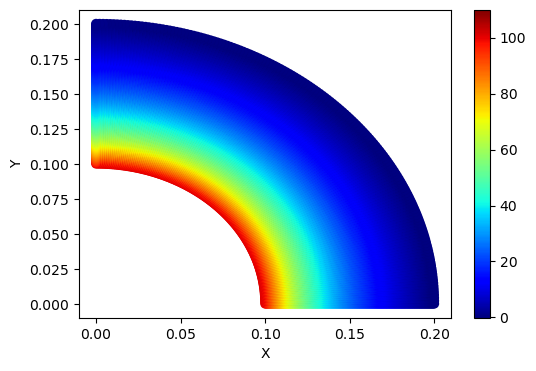

In [58]:
plt.figure(figsize=(6, 4))
X = R * np.cos(THETA)
Y = R * np.sin(THETA)
scatter = plt.scatter(X.flatten(), Y.flatten(), c=predicted_sigma_rr, cmap='jet', s=50, edgecolors='k', linewidths=0.005, vmax=0, vmin=110)
cbar = plt.colorbar(scatter)
#cbar.set_label('Predicted Sigma_rr')
# plt.xlim(0, 0.3)  # Set x-axis limits
# plt.ylim(-0.1, 0.3)  # Set y-axis limits
plt.xlabel('X')
plt.ylabel('Y')
#plt.title('Stress Distribution (Sigma_rr)')
plt.show()

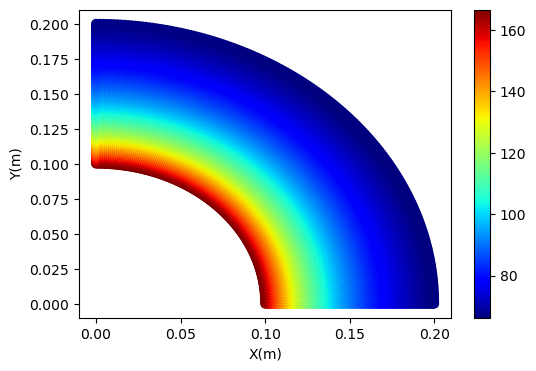

In [52]:

plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=-predicted_sigma_thetatheta,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
#cbar.set_label('Predicted Tangential Stress')

# Set axis labels and title
plt.xlabel('X(m)')
plt.ylabel('Y(m)')
#plt.title('')
plt.show()


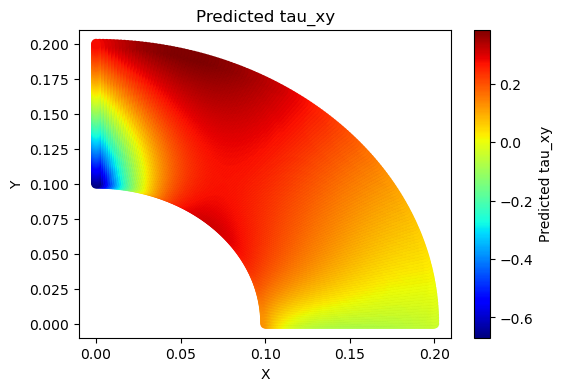

In [20]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=predicted_sigma_rtheta,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted tau_xy')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Predicted tau_xy')
plt.show()


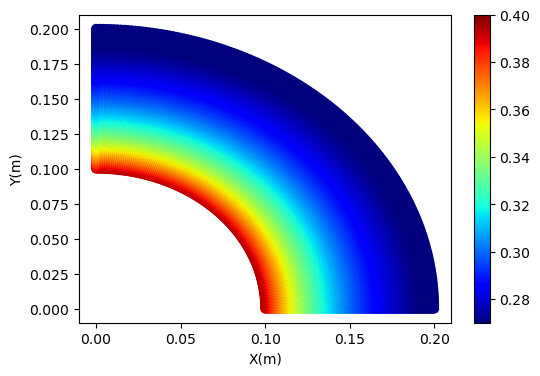

In [53]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=-u_r, \
                      cmap='jet', s=50, edgecolors='k', linewidths=0.005, vmin=0.27, vmax=0.4)

# Add colorbar
cbar = plt.colorbar(scatter)
#cbar.set_label('Radial Displacement (Predicted)')

# Set axis labels and title
plt.xlabel('X(m)')
plt.ylabel('Y(m)')
#plt.title('variation of U')

plt.show()


In [11]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=y_disp,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('variation of V')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('variation of V')

# Add grid lines
# plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


NameError: name 'y_disp' is not defined

<Figure size 600x400 with 0 Axes>

In [41]:
num_points = 151
r1 = 0.1
r2 = 0.2
P = 100
E = 50
nu = 0.3
r = np.linspace(0.1, 0.2, num_points)
ninety = np.pi/2
theta = np.linspace(0, ninety, num_points)
R, THETA = np.meshgrid(r, theta)
s_rr_anal = (P * r1**2) / (r2**2 - r1**2) * (1 - r2**2/R**2)
s_theta_anal = (P * r1**2) / (r2**2 - r1**2) * (1 + r2**2/R**2)
u_rr_anal = (r1**2 * P * R) / (E * (r2**2 - r1**2)) * ((1 - nu) + (1 + nu) * r2**2/r**2)

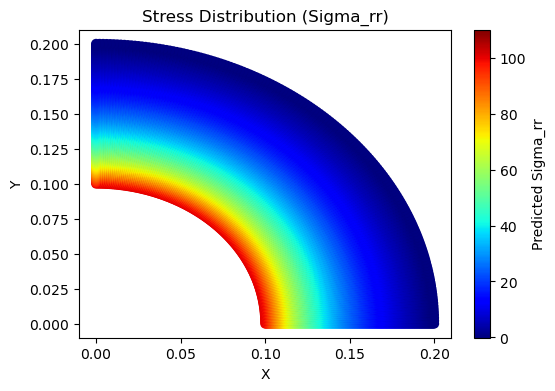

In [ ]:
plt.figure(figsize=(6, 4))
X = R * np.cos(THETA)
Y = R * np.sin(THETA)
scatter = plt.scatter(X.flatten(), Y.flatten(), c=-s_rr_anal, cmap='jet', s=50, edgecolors='k', linewidths=0.005, vmax=0, vmin=110)
cbar = plt.colorbar(scatter)
#cbar.set_label('Predicted Sigma_rr')
# plt.xlim(0, 0.3)  # Set x-axis limits
# plt.ylim(-0.1, 0.3)  # Set y-axis limits
plt.xlabel('X')
plt.ylabel('Y')
#plt.title('Stress Distribution (Sigma_rr)')
plt.show()

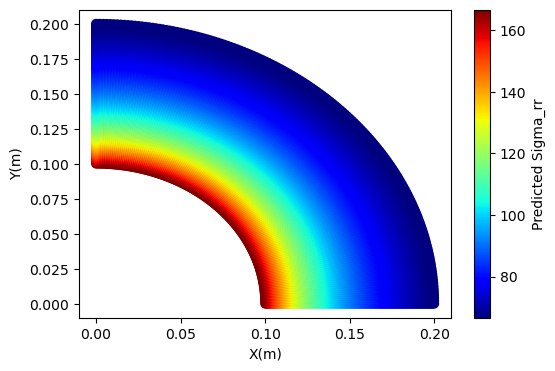

In [45]:
plt.figure(figsize=(6, 4))
X = R * np.cos(THETA)
Y = R * np.sin(THETA)
scatter = plt.scatter(X.flatten(), Y.flatten(), c=s_theta_anal, cmap='jet', s=50, edgecolors='k', linewidths=0.005)
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted Sigma_rr')
# plt.xlim(0, 0.3)  # Set x-axis limits
# plt.ylim(-0.1, 0.3)  # Set y-axis limits
plt.xlabel('X(m)')
plt.ylabel('Y(m)')
#plt.title('Stress Distribution (Sigma_rr)')
plt.show()

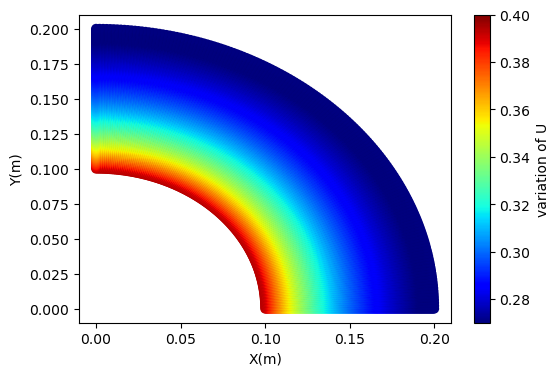

In [44]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=u_rr_anal, \
                      cmap='jet', s=50, edgecolors='k', linewidths=0.005, vmin=0.27, vmax=0.4)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('variation of U')

# Set axis labels and title
plt.xlabel('X(m)')
plt.ylabel('Y(m)')
#plt.title('variation of U')

plt.show()
